In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import silhouette_score

# 1. Load data + model
df = pd.read_csv("train_data.csv")
X = np.load("user_vectors.npy")
labels = np.load("cluster_labels.npy")
model = joblib.load("kmeans_model.pkl")

print("User feature matrix shape:", X.shape)
print("Number of clusters:", model.n_clusters)

# Genre columns (same assumption as before: start after 'Medium')
genre_cols = df.columns[8:]
genre_df = df[genre_cols]

# 2. Recompute silhouette score (testing the model quality)
score = silhouette_score(X, labels)
print(f"\nSilhouette Score (recomputed): {score:.3f}")

# 3. Cluster size summary
print("\nCluster sizes:")
unique, counts = np.unique(labels, return_counts=True)
for c, cnt in zip(unique, counts):
    print(f"  Cluster {c}: {cnt} users")

# 4. Describe each cluster by its top genres
def describe_cluster(cluster_id, top_n=5):
    cluster_users = X[labels == cluster_id]
    avg_pref = cluster_users.mean(axis=0)  # average genre preference
    top_idx = np.argsort(avg_pref)[::-1][:top_n]
    print(f"\nCluster {cluster_id} — top {top_n} genres:")
    for i in top_idx:
        print(f"  {genre_cols[i]} (avg score {avg_pref[i]:.3f})")

for c in range(model.n_clusters):
    describe_cluster(c)


User feature matrix shape: (200, 85)
Number of clusters: 4

Silhouette Score (recomputed): 0.062

Cluster sizes:
  Cluster 0: 63 users
  Cluster 1: 45 users
  Cluster 2: 39 users
  Cluster 3: 53 users

Cluster 0 — top 5 genres:
  Platformer (avg score 0.248)
  Adventure (avg score 0.083)
  Puzzle (avg score 0.081)
  Role Playing (avg score 0.071)
  Shoot 'em up (avg score 0.070)

Cluster 1 — top 5 genres:
  Puzzle (avg score 0.198)
  Adventure (avg score 0.109)
  Role Playing (avg score 0.082)
  Shoot 'em up (avg score 0.080)
  Platformer (avg score 0.076)

Cluster 2 — top 5 genres:
  Action (avg score 0.110)
  Sports (avg score 0.087)
  Action-Adventure (avg score 0.082)
  Simulation (avg score 0.074)
  Platformer (avg score 0.069)

Cluster 3 — top 5 genres:
  Role Playing (avg score 0.230)
  Turn Based (avg score 0.138)
  Adventure (avg score 0.092)
  Platformer (avg score 0.092)
  Action-RPG (avg score 0.091)


In [2]:
def make_user_vector_from_genres(preferred_genres):
    """
    Create a simple user vector with 1.0 for preferred genres and 0.0 for others.
    """
    vec = np.zeros(len(genre_cols))
    for g in preferred_genres:
        if g in genre_cols:
            idx = list(genre_cols).index(g)
            vec[idx] = 1.0
        else:
            print(f"(Warning) Genre '{g}' not found in genre columns.")
    return vec

def recommend_games(preferred_genres, n_recs=5):
    """
    Given a list like ['Action', 'RPG'], recommend n_recs games that match best.
    """
    user_vec = make_user_vector_from_genres(preferred_genres)

    # Predict cluster for this user
    cluster = model.predict([user_vec])[0]
    print(f"\nUser with genres {preferred_genres} is assigned to cluster {cluster}")

    # Score each game by how many preferred genres it shares
    # (dot product of game genre row with user vector)
    scores = genre_df.values.dot(user_vec)

    # Sort games by score descending
    top_idx = np.argsort(scores)[::-1]

    print(f"\nTop {n_recs} recommended games:")
    shown = 0
    for i in top_idx:
        if scores[i] <= 0:
            break  # no more matching genres
        row = df.iloc[i]
        print(f"- {row['GameName']} | Genres: {row['Genre']} | Publisher: {row['Publisher']}")
        shown += 1
        if shown >= n_recs:
            break

# Example: try a fake user who likes Action + RPG
recommend_games(["Action", "Role-Playing Game (RPG)"], n_recs=5)


(Warning) Genre 'Role-Playing Game (RPG)' not found in genre columns.

User with genres ['Action', 'Role-Playing Game (RPG)'] is assigned to cluster 2

Top 5 recommended games:
- Glaive: Brick Breaker | Genres: ['Action'] | Publisher: Blue Sunset Games
- Five Nights at Freddy's: Sister Location (EU) | Genres: ['Action'] | Publisher: Clickteam
- Perfect Universe | Genres: ['Action'] | Publisher: Excalibur Games
- Radio Squid (EU) | Genres: ['Action'] | Publisher: Ratalaika Games
- 60 Parsecs! | Genres: ['Action'] | Publisher: Robot Gentleman


Explained variance ratios: [0.11002403 0.09413837]


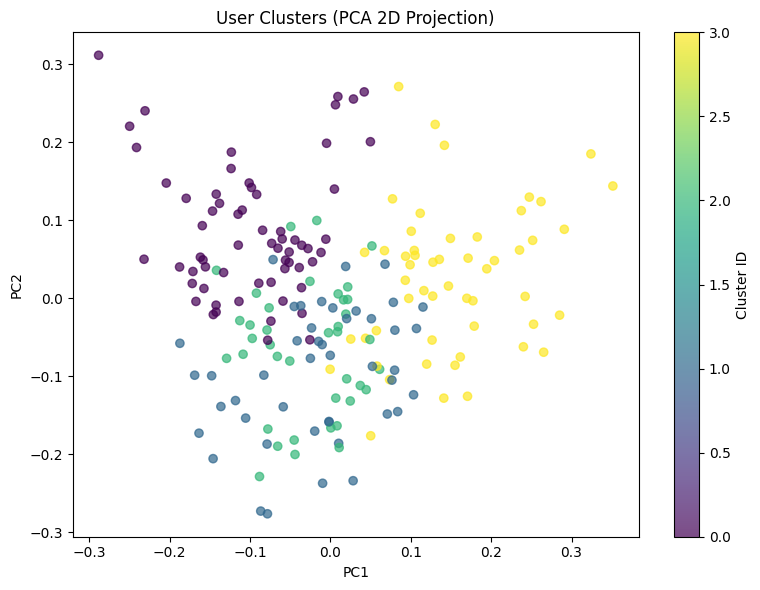

In [3]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Run PCA to reduce user vectors to 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

print("Explained variance ratios:", pca.explained_variance_ratio_)

# 2. Scatter plot colored by cluster label
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, alpha=0.7)

plt.title("User Clusters (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# Add colorbar so each color = cluster id
cbar = plt.colorbar(scatter)
cbar.set_label("Cluster ID")

plt.tight_layout()
plt.show()
